## 1. Load the Dataset

We load the CSV file using pandas to begin our analysis.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('../data/studentInfo.csv')
print('Dataset loaded successfully')

Dataset loaded successfully


## 2. Dataset Shape and Column Names

Understanding the dimensions of the dataset helps us know how many rows (samples) and columns (features) we have.


In [2]:
print(f'Dataset shape: {df.shape}')
print(f'\nNumber of rows: {df.shape[0]}')
print(f'Number of columns: {df.shape[1]}')
print(f'\nColumn names:')
print(df.columns.tolist())

Dataset shape: (32593, 12)

Number of rows: 32593
Number of columns: 12

Column names:
['code_module', 'code_presentation', 'id_student', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result']


## 3. Preview First and Last Rows

Examining the first and last rows gives us a sense of the data content and structure.


In [3]:
print('First 5 rows:')
print(df.head())
print('\n' + '='*80 + '\n')
print('Last 5 rows:')
print(df.tail())

First 5 rows:
  code_module code_presentation  id_student gender                region  \
0         AAA             2013J       11391      M   East Anglian Region   
1         AAA             2013J       28400      F              Scotland   
2         AAA             2013J       30268      F  North Western Region   
3         AAA             2013J       31604      F     South East Region   
4         AAA             2013J       32885      F  West Midlands Region   

       highest_education imd_band age_band  num_of_prev_attempts  \
0       HE Qualification  90-100%     55<=                     0   
1       HE Qualification   20-30%    35-55                     0   
2  A Level or Equivalent   30-40%    35-55                     0   
3  A Level or Equivalent   50-60%    35-55                     0   
4     Lower Than A Level   50-60%     0-35                     0   

   studied_credits disability final_result  
0              240          N         Pass  
1               60          N 

In [14]:
df.nunique()

code_module                 7
code_presentation           4
id_student              28785
gender                      2
region                     13
highest_education           5
imd_band                   10
age_band                    3
num_of_prev_attempts        7
studied_credits            61
disability                  2
final_result                4
dtype: int64

## 4. Data Types

Knowing the data type of each column is crucial for determining appropriate analysis and preprocessing techniques.


In [4]:
print('Data types:')
print(df.dtypes)
print('\n' + '='*80 + '\n')
print('Data type summary:')
print(df.dtypes.value_counts())

Data types:
code_module               str
code_presentation         str
id_student              int64
gender                    str
region                    str
highest_education         str
imd_band                  str
age_band                  str
num_of_prev_attempts    int64
studied_credits         int64
disability                str
final_result              str
dtype: object


Data type summary:
str      9
int64    3
Name: count, dtype: int64


## 5. Missing Value Analysis

Identifying missing values helps us understand data quality and determine handling strategies. We check both count and percentage of missing values.


In [5]:
missing_data = pd.DataFrame({
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df)) * 100
})

missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

if len(missing_data) == 0:
    print('No missing values found in the dataset.')
else:
    print('Missing values:')
    print(missing_data)

Missing values:
          Missing_Count  Missing_Percentage
imd_band           1111            3.408707


## 6. Duplicate Row Check

Duplicates can distort our analysis. We check for completely identical rows and rows with duplicate key identifiers.


In [6]:
# Check for completely duplicate rows
total_duplicates = df.duplicated().sum()
print(f'Total completely duplicate rows: {total_duplicates}')
print(f'Percentage of duplicates: {(total_duplicates / len(df)) * 100:.2f}%')

# Check for duplicates in each column
print('\nDuplicate counts per column:')
for col in df.columns:
    dup_count = df[col].duplicated().sum()
    if dup_count > 0:
        print(f'{col}: {dup_count} duplicates ({(dup_count/len(df))*100:.2f}%)')

Total completely duplicate rows: 0
Percentage of duplicates: 0.00%

Duplicate counts per column:
code_module: 32586 duplicates (99.98%)
code_presentation: 32589 duplicates (99.99%)
id_student: 3808 duplicates (11.68%)
gender: 32591 duplicates (99.99%)
region: 32580 duplicates (99.96%)
highest_education: 32588 duplicates (99.98%)
imd_band: 32582 duplicates (99.97%)
age_band: 32590 duplicates (99.99%)
num_of_prev_attempts: 32586 duplicates (99.98%)
studied_credits: 32532 duplicates (99.81%)
disability: 32591 duplicates (99.99%)
final_result: 32589 duplicates (99.99%)


## 7. Summary Statistics for Numeric Columns

Descriptive statistics provide insights into the distribution, central tendency, and spread of numeric features.


In [15]:
print('Summary statistics for numeric columns:')
print(df.describe())

Summary statistics for numeric columns:
         id_student  num_of_prev_attempts  studied_credits
count  3.259300e+04          32593.000000     32593.000000
mean   7.066877e+05              0.163225        79.758691
std    5.491673e+05              0.479758        41.071900
min    3.733000e+03              0.000000        30.000000
25%    5.085730e+05              0.000000        60.000000
50%    5.903100e+05              0.000000        60.000000
75%    6.444530e+05              0.000000       120.000000
max    2.716795e+06              6.000000       655.000000


## 8. Overview of Categorical Columns

For categorical columns, we examine unique counts and sample values to understand categorical diversity.


In [18]:
categorical_cols = df.select_dtypes(include=['object']).columns

if len(categorical_cols) > 0:
    for col in categorical_cols:
        print(f'{col}:')
        print(f'  Unique values: {df[col].nunique()}')
        print(f'  Sample values: {df[col].unique()}')
        print()
else:
    print('No categorical columns found in the dataset.')

code_module:
  Unique values: 7
  Sample values: <StringArray>
['AAA', 'BBB', 'CCC', 'DDD', 'EEE', 'FFF', 'GGG']
Length: 7, dtype: str

code_presentation:
  Unique values: 4
  Sample values: <StringArray>
['2013J', '2014J', '2013B', '2014B']
Length: 4, dtype: str

gender:
  Unique values: 2
  Sample values: <StringArray>
['M', 'F']
Length: 2, dtype: str

region:
  Unique values: 13
  Sample values: <StringArray>
[ 'East Anglian Region',             'Scotland', 'North Western Region',
    'South East Region', 'West Midlands Region',                'Wales',
         'North Region',         'South Region',              'Ireland',
    'South West Region', 'East Midlands Region',     'Yorkshire Region',
        'London Region']
Length: 13, dtype: str

highest_education:
  Unique values: 5
  Sample values: <StringArray>
[           'HE Qualification',       'A Level or Equivalent',
          'Lower Than A Level', 'Post Graduate Qualification',
             'No Formal quals']
Length: 5, dtype

C:\Users\Dell\AppData\Local\Temp\ipykernel_38548\3647526207.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


## 9. Value Counts for Key Categorical or Target-like Columns

Detailed frequency analysis of categorical columns helps us identify class distributions and potential imbalances.


In [9]:
for col in categorical_cols:
    print(f'Value counts for {col}:')
    print(df[col].value_counts())
    print(f'\nPercentage distribution:')
    print(df[col].value_counts(normalize=True) * 100)
    print('\n' + '='*80 + '\n')

Value counts for code_module:
code_module
BBB    7909
FFF    7762
DDD    6272
CCC    4434
EEE    2934
GGG    2534
AAA     748
Name: count, dtype: int64

Percentage distribution:
code_module
BBB    24.265947
FFF    23.814930
DDD    19.243396
CCC    13.604148
EEE     9.001933
GGG     7.774676
AAA     2.294971
Name: proportion, dtype: float64


Value counts for code_presentation:
code_presentation
2014J    11260
2013J     8845
2014B     7804
2013B     4684
Name: count, dtype: int64

Percentage distribution:
code_presentation
2014J    34.547295
2013J    27.137729
2014B    23.943792
2013B    14.371184
Name: proportion, dtype: float64


Value counts for gender:
gender
M    17875
F    14718
Name: count, dtype: int64

Percentage distribution:
gender
M    54.843064
F    45.156936
Name: proportion, dtype: float64


Value counts for region:
region
Scotland                3446
East Anglian Region     3340
London Region           3216
South Region            3092
North Western Region    2906
West M

## 10. Student Distribution and Characteristics Analysis

Comprehensive analysis of student distribution across modules and presentations, along with relationships between key demographic and academic characteristics.


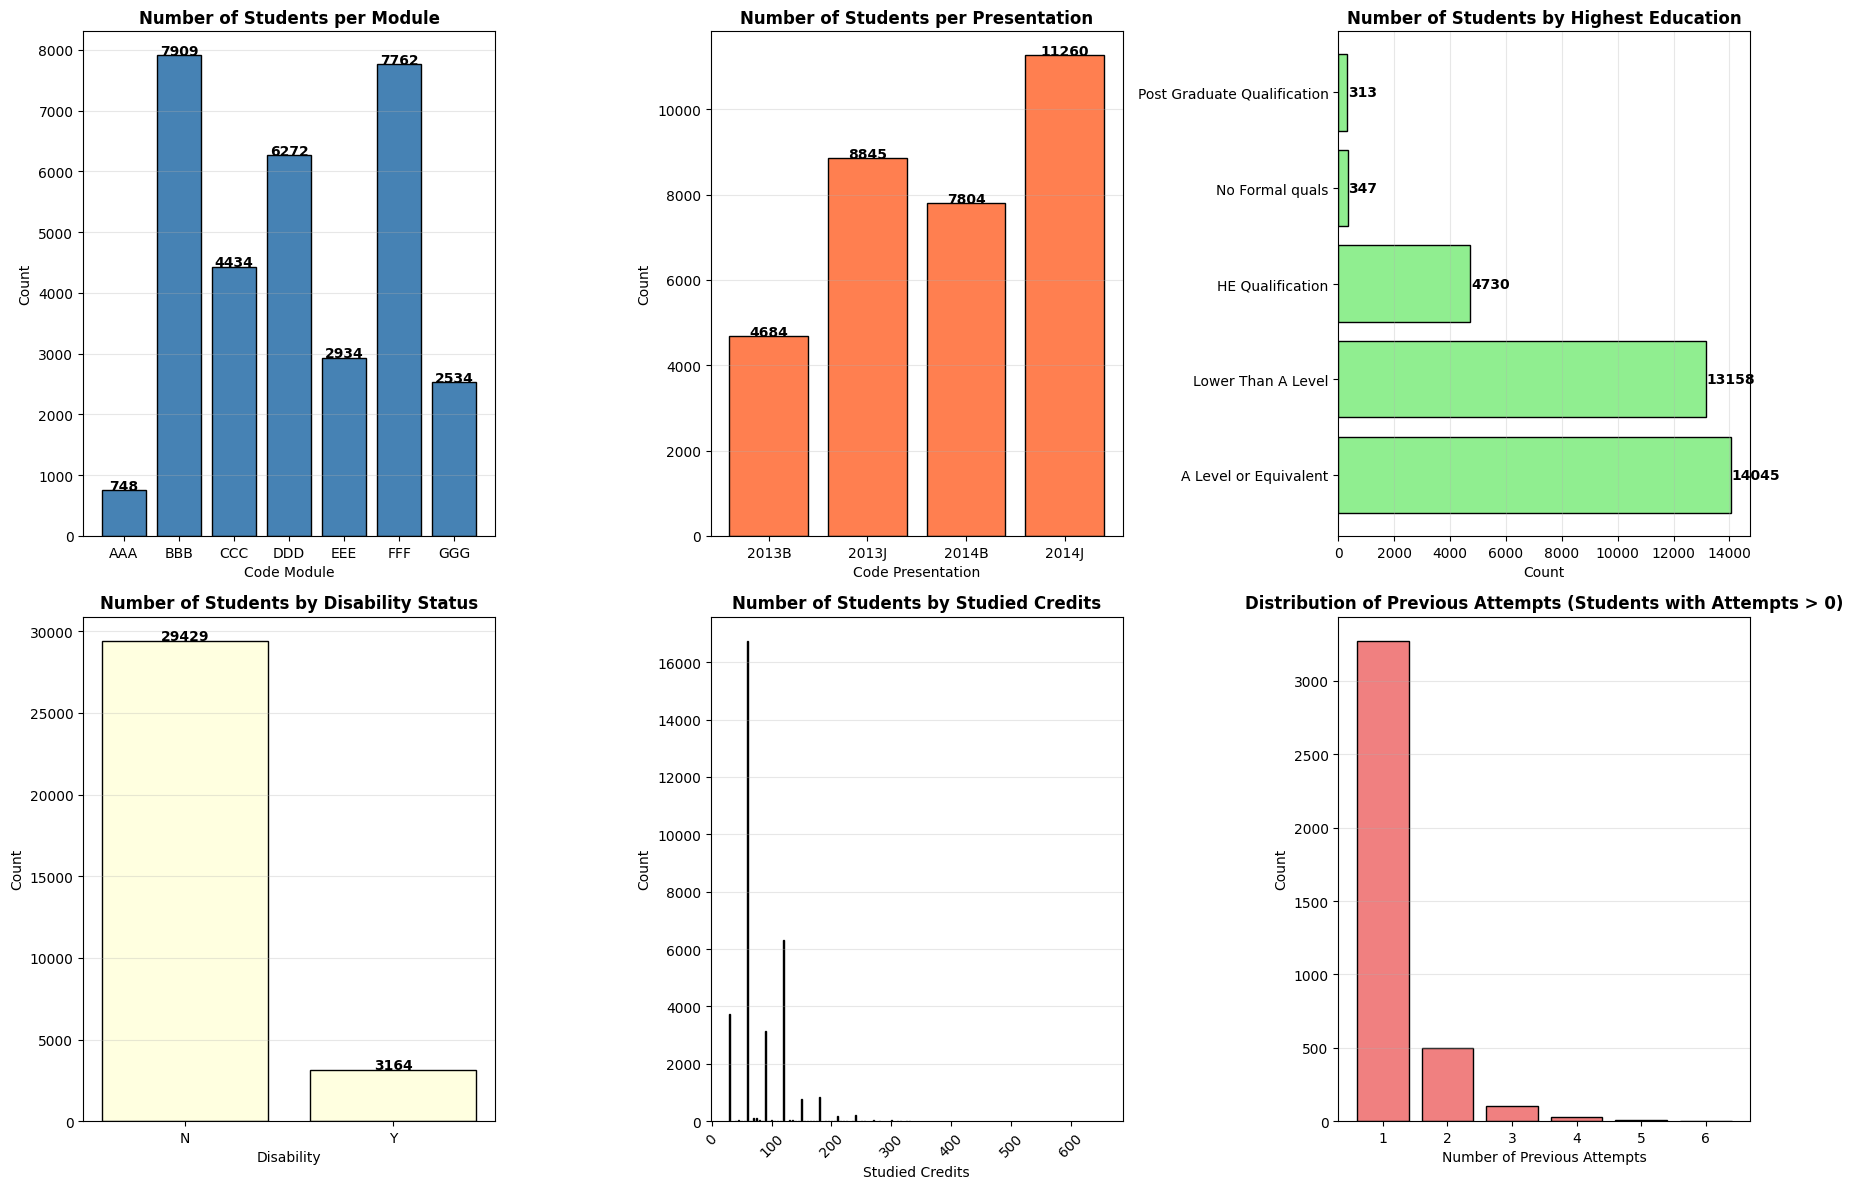

In [19]:
# Student Distribution and Characteristics Analysis
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Count of students in each module
student_module = df['code_module'].value_counts().sort_index()
axes[0, 0].bar(student_module.index, student_module.values, color='steelblue', edgecolor='black')
axes[0, 0].set_title('Number of Students per Module', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Code Module')
axes[0, 0].set_ylabel('Count')
axes[0, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate(student_module.values):
    axes[0, 0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# 2. Count of students in each presentation
student_presentation = df['code_presentation'].value_counts().sort_index()
axes[0, 1].bar(student_presentation.index, student_presentation.values, color='coral', edgecolor='black')
axes[0, 1].set_title('Number of Students per Presentation', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Code Presentation')
axes[0, 1].set_ylabel('Count')
axes[0, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(student_presentation.values):
    axes[0, 1].text(i, v + 5, str(v), ha='center', fontweight='bold')

# 3. Highest education vs number of students
education_counts = df['highest_education'].value_counts()
axes[0, 2].barh(education_counts.index, education_counts.values, color='lightgreen', edgecolor='black')
axes[0, 2].set_title('Number of Students by Highest Education', fontsize=12, fontweight='bold')
axes[0, 2].set_xlabel('Count')
axes[0, 2].grid(axis='x', alpha=0.3)
for i, v in enumerate(education_counts.values):
    axes[0, 2].text(v + 20, i, str(v), va='center', fontweight='bold')

# 4. Disability vs number of students
disability_counts = df['disability'].value_counts()
axes[1, 0].bar(disability_counts.index, disability_counts.values, color='lightyellow', edgecolor='black')
axes[1, 0].set_title('Number of Students by Disability Status', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Disability')
axes[1, 0].set_ylabel('Count')
axes[1, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate(disability_counts.values):
    axes[1, 0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# 5. Studied credits vs number of students
credits_counts = df['studied_credits'].value_counts().sort_index()
axes[1, 1].bar(credits_counts.index, credits_counts.values, color='lightblue', edgecolor='black')
axes[1, 1].set_title('Number of Students by Studied Credits', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Studied Credits')
axes[1, 1].set_ylabel('Count')
axes[1, 1].grid(axis='y', alpha=0.3)
axes[1, 1].tick_params(axis='x', rotation=45)

# 6. Count of num_of_prev_attempts for students with attempts > 0
prev_attempts_df = df[df['num_of_prev_attempts'] > 0].groupby('id_student')['num_of_prev_attempts'].first().value_counts().sort_index()
axes[1, 2].bar(prev_attempts_df.index, prev_attempts_df.values, color='lightcoral', edgecolor='black')
axes[1, 2].set_title('Distribution of Previous Attempts (Students with Attempts > 0)', fontsize=12, fontweight='bold')
axes[1, 2].set_xlabel('Number of Previous Attempts')
axes[1, 2].set_ylabel('Count')
axes[1, 2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 11. Advanced Student Analysis: Previous Attempts and Withdrawal Patterns

Detailed analysis of students with previous attempts and those with withdrawal outcomes, examining relationships with academic and demographic factors.


Correlation Matrix:
                      id_student  num_of_prev_attempts  studied_credits
id_student              1.000000              0.011473        -0.003868
num_of_prev_attempts    0.011473              1.000000         0.181729
studied_credits        -0.003868              0.181729         1.000000




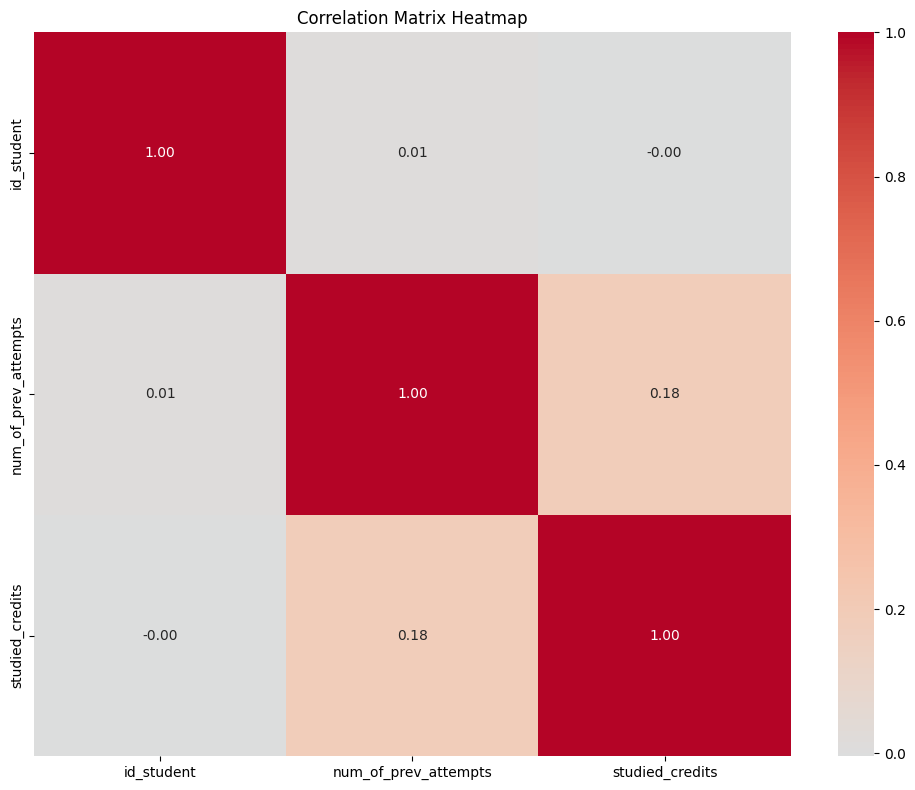

In [11]:
# Advanced Student Analysis: Previous Attempts and Withdrawal Patterns
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 6. Students with num_of_prev_attempts > 0: relationship with studied_credits, final_result, imd_band, age_band, highest_education
prev_attempts_students = df[df['num_of_prev_attempts'] > 0].copy()

# 6a. Studied credits distribution for students with previous attempts
studied_prev = prev_attempts_students['studied_credits'].value_counts().sort_index()
axes[0, 0].bar(studied_prev.index, studied_prev.values, color='mediumpurple', edgecolor='black')
axes[0, 0].set_title('Studied Credits Distribution (Students with Previous Attempts)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Studied Credits')
axes[0, 0].set_ylabel('Count')
axes[0, 0].grid(axis='y', alpha=0.3)

# 6b. Final result distribution for students with previous attempts
final_result_prev = prev_attempts_students['final_result'].value_counts()
colors_result = ['#ff6b6b', '#4ecdc4', '#45b7d1', '#ffa07a']
axes[0, 1].bar(final_result_prev.index, final_result_prev.values, color=colors_result, edgecolor='black')
axes[0, 1].set_title('Final Result Distribution (Students with Previous Attempts)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Final Result')
axes[0, 1].set_ylabel('Count')
axes[0, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(final_result_prev.values):
    axes[0, 1].text(i, v + 10, str(v), ha='center', fontweight='bold')

# 6c. IMD Band and Age Band heatmap for students with previous attempts
prev_crosstab = pd.crosstab(prev_attempts_students['imd_band'], prev_attempts_students['age_band'])
sns.heatmap(prev_crosstab, annot=True, fmt='d', cmap='YlOrRd', ax=axes[1, 0], cbar_kws={'label': 'Count'})
axes[1, 0].set_title('IMD Band vs Age Band (Students with Previous Attempts)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Age Band')
axes[1, 0].set_ylabel('IMD Band')

# 6d. Highest education for students with previous attempts
education_prev = prev_attempts_students['highest_education'].value_counts()
axes[1, 1].barh(education_prev.index, education_prev.values, color='lightseagreen', edgecolor='black')
axes[1, 1].set_title('Highest Education (Students with Previous Attempts)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Count')
axes[1, 1].grid(axis='x', alpha=0.3)
for i, v in enumerate(education_prev.values):
    axes[1, 1].text(v + 5, i, str(v), va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print('\n=== Students with Previous Attempts Summary ===')
print(f'Total students with previous attempts: {len(prev_attempts_students)}')
print(f'\nBreakdown by final result:\n{prev_attempts_students["final_result"].value_counts()}')

# 7. Students with final_result = Withdrawal: relationships with studied_credits, num_of_prev_attempts, imd_band, age_band, highest_education
withdrawal_students = df[df['final_result'] == 'Withdrawn'].copy()

fig2, axes2 = plt.subplots(2, 3, figsize=(18, 10))

# 7a. Studied credits for withdrawal students
studied_withdrawal = withdrawal_students['studied_credits'].value_counts().sort_index()
axes2[0, 0].bar(studied_withdrawal.index, studied_withdrawal.values, color='salmon', edgecolor='black')
axes2[0, 0].set_title('Studied Credits (Withdrawn Students)', fontsize=12, fontweight='bold')
axes2[0, 0].set_xlabel('Studied Credits')
axes2[0, 0].set_ylabel('Count')
axes2[0, 0].grid(axis='y', alpha=0.3)

# 7b. Previous attempts for withdrawal students
prev_attempts_withdrawal = withdrawal_students['num_of_prev_attempts'].value_counts().sort_index()
axes2[0, 1].bar(prev_attempts_withdrawal.index, prev_attempts_withdrawal.values, color='khaki', edgecolor='black')
axes2[0, 1].set_title('Previous Attempts (Withdrawn Students)', fontsize=12, fontweight='bold')
axes2[0, 1].set_xlabel('Number of Previous Attempts')
axes2[0, 1].set_ylabel('Count')
axes2[0, 1].grid(axis='y', alpha=0.3)

# 7c. IMD Band for withdrawal students
imd_withdrawal = withdrawal_students['imd_band'].value_counts()
axes2[0, 2].barh(imd_withdrawal.index, imd_withdrawal.values, color='lightsteelblue', edgecolor='black')
axes2[0, 2].set_title('IMD Band (Withdrawn Students)', fontsize=12, fontweight='bold')
axes2[0, 2].set_xlabel('Count')
axes2[0, 2].grid(axis='x', alpha=0.3)

# 7d. Age Band for withdrawal students
age_withdrawal = withdrawal_students['age_band'].value_counts()
axes2[1, 0].bar(age_withdrawal.index, age_withdrawal.values, color='lightpink', edgecolor='black')
axes2[1, 0].set_title('Age Band (Withdrawn Students)', fontsize=12, fontweight='bold')
axes2[1, 0].set_xlabel('Age Band')
axes2[1, 0].set_ylabel('Count')
axes2[1, 0].grid(axis='y', alpha=0.3)
axes2[1, 0].tick_params(axis='x', rotation=45)

# 7e. Highest education for withdrawal students
education_withdrawal = withdrawal_students['highest_education'].value_counts()
axes2[1, 1].barh(education_withdrawal.index, education_withdrawal.values, color='thistle', edgecolor='black')
axes2[1, 1].set_title('Highest Education (Withdrawn Students)', fontsize=12, fontweight='bold')
axes2[1, 1].set_xlabel('Count')
axes2[1, 1].grid(axis='x', alpha=0.3)

# 7f. Disability status for withdrawal students
disability_withdrawal = withdrawal_students['disability'].value_counts()
axes2[1, 2].bar(disability_withdrawal.index, disability_withdrawal.values, color='plum', edgecolor='black')
axes2[1, 2].set_title('Disability Status (Withdrawn Students)', fontsize=12, fontweight='bold')
axes2[1, 2].set_xlabel('Disability')
axes2[1, 2].set_ylabel('Count')
axes2[1, 2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print('\n=== Withdrawn Students Summary ===')
print(f'Total withdrawn students: {len(withdrawal_students)}')
print(f'Percentage of total students: {(len(withdrawal_students)/len(df)*100):.2f}%')
print(f'\nBreakdown by studied credits:\n{withdrawal_students["studied_credits"].value_counts().sort_index()}')
print(f'\nBreakdown by previous attempts:\n{withdrawal_students["num_of_prev_attempts"].value_counts().sort_index()}')

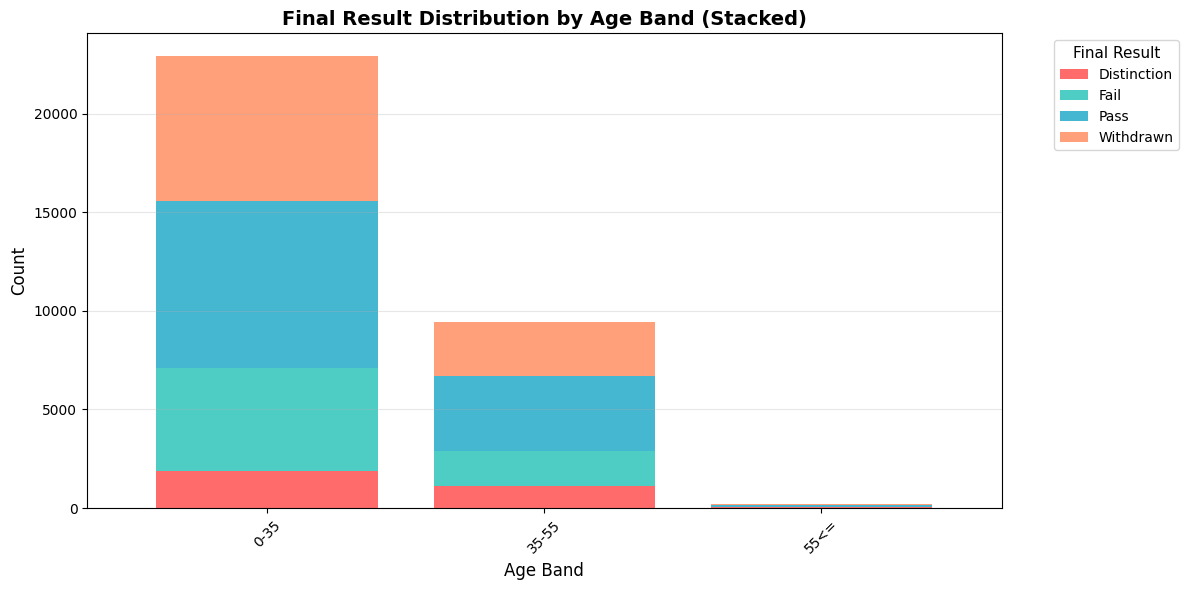


Age Band vs Final Result Crosstab:
final_result  Distinction  Fail  Pass  Withdrawn
age_band                                        
0-35                 1863  5231  8469       7381
35-55                1120  1792  3800       2721
55<=                   41    29    92         54

Percentage distribution by Final Result within each Age Band:
final_result  Distinction       Fail       Pass  Withdrawn
age_band                                                  
0-35             8.119770  22.798989  36.911611  32.169630
35-55           11.873211  18.997138  40.284109  28.845542
55<=            18.981481  13.425926  42.592593  25.000000


In [22]:
# Age Band vs Final Result Analysis (all students)
age_result_crosstab = pd.crosstab(df['age_band'], df['final_result'])
fig_age_result, ax_age = plt.subplots(figsize=(12, 6))
age_result_crosstab.plot(kind='bar', ax=ax_age, width=0.8, stacked=True, color=['#ff6b6b', '#4ecdc4', '#45b7d1', '#ffa07a'])
ax_age.set_title('Final Result Distribution by Age Band (Stacked)', fontsize=14, fontweight='bold')
ax_age.set_xlabel('Age Band', fontsize=12)
ax_age.set_ylabel('Count', fontsize=12)
ax_age.legend(title='Final Result', fontsize=10, title_fontsize=11, bbox_to_anchor=(1.05, 1), loc='upper left')
ax_age.grid(axis='y', alpha=0.3)
ax_age.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

print('\nAge Band vs Final Result Crosstab:')
print(age_result_crosstab)
print('\nPercentage distribution by Final Result within each Age Band:')
print(age_result_crosstab.div(age_result_crosstab.sum(axis=1), axis=0) * 100)